In [ ]:
from google.colab import files
files.upload()  # upload kaggle.json here
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d berkanoztas/synthetic-transaction-monitoring-dataset-aml
!unzip synthetic-transaction-monitoring-dataset-aml.zip -d aml_data
import os
os.listdir("aml_data")

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/berkanoztas/synthetic-transaction-monitoring-dataset-aml
License(s): CC-BY-NC-SA-4.0
synthetic-transaction-monitoring-dataset-aml.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  synthetic-transaction-monitoring-dataset-aml.zip
replace aml_data/SAML-D.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: aml_data/SAML-D.csv     


['SAML-D.csv']

Total hours: 7681
After feature engineering: (7513, 37)
Amount features (33): ['hour_of_day', 'day_of_week', 'month', 'is_weekend', 'lag_amount_1', 'lag_amount_2', 'lag_amount_3', 'lag_amount_6', 'lag_amount_12', 'lag_amount_24', 'lag_amount_48', 'lag_amount_72', 'lag_amount_168', 'lag_count_1', 'lag_avg_ticket_1', 'lag_count_24', 'lag_avg_ticket_24', 'lag_count_168', 'lag_avg_ticket_168', 'roll_mean_4', 'roll_mean_24', 'roll_mean_168', 'roll_std_24', 'roll_std_168', 'roll_max_24', 'roll_min_24', 'roll_mean_count_24', 'roll_mean_avg_ticket_24', 'roll_std_avg_ticket_24', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']
Count  features (19):  ['hour_of_day', 'day_of_week', 'month', 'is_weekend', 'lag_count_1', 'lag_count_24', 'lag_count_168', 'roll_mean_4', 'roll_mean_24', 'roll_mean_168', 'roll_std_24', 'roll_std_168', 'roll_max_24', 'roll_min_24', 'roll_mean_count_24', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']

===== Amount Forecast =====
  MAE       : 636,164.0031
  RMSE      : 786,4

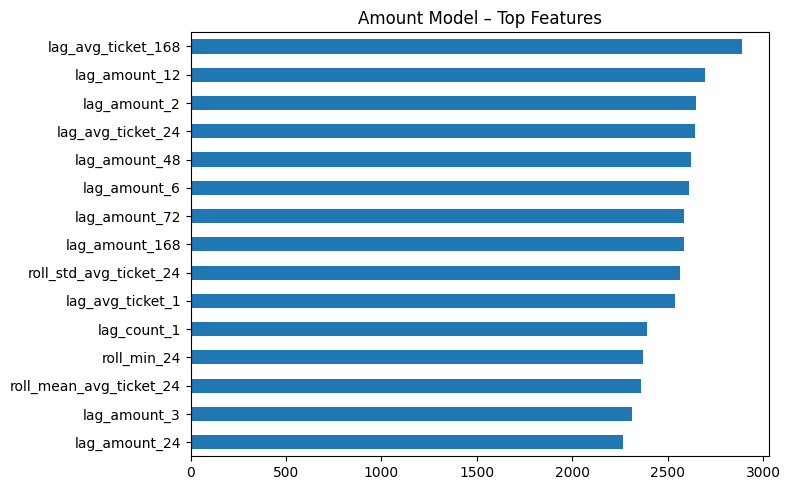

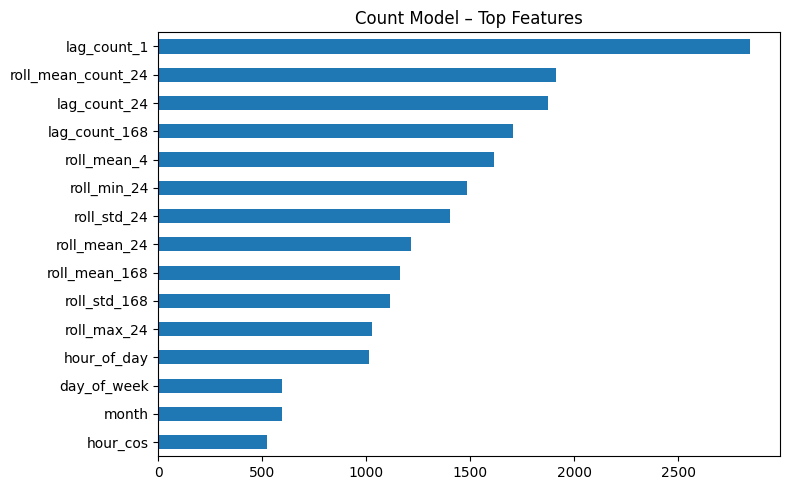

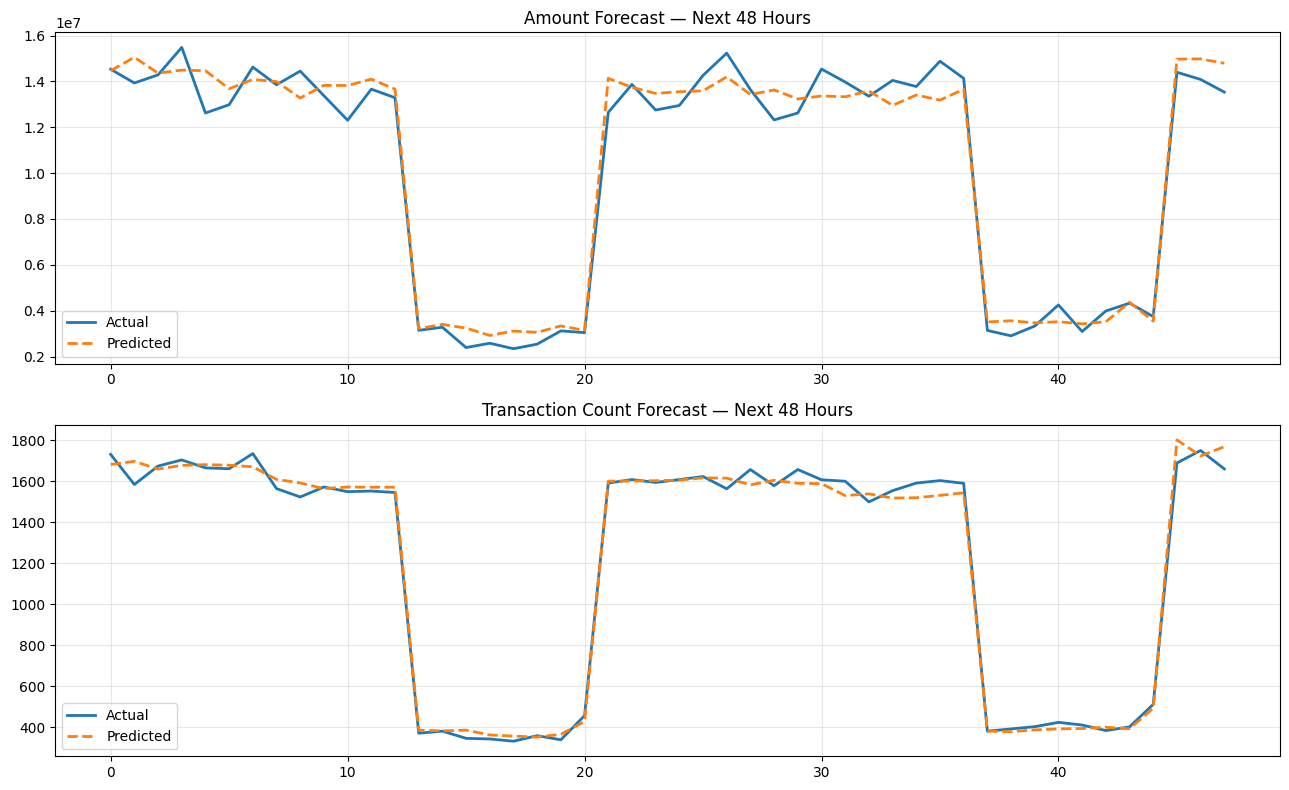

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1) Load data

df = pd.read_csv("aml_data/SAML-D.csv")
df["timestamp"] = pd.to_datetime(df["Date"] + " " + df["Time"])
df = df.sort_values("timestamp").reset_index(drop=True)

hourly = (
    df.set_index("timestamp")
      .resample("H")
      .agg(
          Amount=("Amount", "sum"),
          tx_count=("Amount", "count")
      )
      .reset_index()
)

hourly["Amount"]   = hourly["Amount"].fillna(0)
hourly["tx_count"] = hourly["tx_count"].fillna(0)

print(f"Total hours: {len(hourly)}")

# 3) Feature engineering (LEAKAGE-FREE)

hourly["hour_of_day"]  = hourly["timestamp"].dt.hour
hourly["day_of_week"]  = hourly["timestamp"].dt.dayofweek
hourly["month"]        = hourly["timestamp"].dt.month
hourly["is_weekend"]   = (hourly["day_of_week"] >= 5).astype(int)

# avg_ticket
hourly["avg_ticket"] = hourly["Amount"] / hourly["tx_count"].replace(0, np.nan)
hourly["avg_ticket"] = hourly["avg_ticket"].fillna(0)

# Lag features
lags_main = [1, 2, 3, 6, 12, 24, 48, 72, 168]

for lag in lags_main:
    hourly[f"lag_amount_{lag}"] = hourly["Amount"].shift(lag)

for lag in [1, 24, 168]:
    hourly[f"lag_count_{lag}"]      = hourly["tx_count"].shift(lag)
    hourly[f"lag_avg_ticket_{lag}"] = hourly["avg_ticket"].shift(lag)

amount_shifted = hourly["Amount"].shift(1)
count_shifted  = hourly["tx_count"].shift(1)
ticket_shifted = hourly["avg_ticket"].shift(1)

hourly["roll_mean_4"]             = amount_shifted.rolling(4).mean()
hourly["roll_mean_24"]            = amount_shifted.rolling(24).mean()
hourly["roll_mean_168"]           = amount_shifted.rolling(168).mean()
hourly["roll_std_24"]             = amount_shifted.rolling(24).std()
hourly["roll_std_168"]            = amount_shifted.rolling(168).std()
hourly["roll_max_24"]             = amount_shifted.rolling(24).max()
hourly["roll_min_24"]             = amount_shifted.rolling(24).min()

hourly["roll_mean_count_24"]      = count_shifted.rolling(24).mean()
hourly["roll_mean_avg_ticket_24"] = ticket_shifted.rolling(24).mean()
hourly["roll_std_avg_ticket_24"]  = ticket_shifted.rolling(24).std()

# ── Cyclical encoding ──
hourly["hour_sin"] = np.sin(2 * np.pi * hourly["hour_of_day"] / 24)
hourly["hour_cos"] = np.cos(2 * np.pi * hourly["hour_of_day"] / 24)
hourly["dow_sin"]  = np.sin(2 * np.pi * hourly["day_of_week"] / 7)
hourly["dow_cos"]  = np.cos(2 * np.pi * hourly["day_of_week"] / 7)

# 4) Drop NaN rows created by lags/rolling
hourly_fe = hourly.dropna().reset_index(drop=True)
print(f"After feature engineering: {hourly_fe.shape}")

# 5) Train / Test split
H = 48  # forecast horizon

amount_features = [c for c in hourly_fe.columns if c not in [
    "timestamp", "Amount", "tx_count", "avg_ticket"
]]

# Count model excludes amount lags & amount rolling
count_exclude = {"timestamp", "Amount", "tx_count", "avg_ticket"} | \
                {c for c in hourly_fe.columns if "amount" in c.lower() or "ticket" in c.lower()}
count_features = [c for c in hourly_fe.columns if c not in count_exclude]

train = hourly_fe.iloc[:-H]
test  = hourly_fe.iloc[-H:]

X_train_amt = train[amount_features]
X_test_amt  = test[amount_features]

X_train_cnt = train[count_features]
X_test_cnt  = test[count_features]

y_train_amount = train["Amount"]
y_test_amount  = test["Amount"]

y_train_count  = train["tx_count"]
y_test_count   = test["tx_count"]

print(f"Amount features ({len(amount_features)}): {amount_features}")
print(f"Count  features ({len(count_features)}):  {count_features}")

# 6) Metrics
def smape(y_true, y_pred, eps=1e-9):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom  = np.maximum((np.abs(y_true) + np.abs(y_pred)) / 2.0, eps)
    return np.mean(np.abs(y_true - y_pred) / denom) * 100

def eval_metrics(y_true, y_pred, label=""):
    metrics = {
        "MAE":      mean_absolute_error(y_true, y_pred),
        "RMSE":     np.sqrt(mean_squared_error(y_true, y_pred)),
        "sMAPE(%)": smape(y_true, y_pred),
        "R2":       r2_score(y_true, y_pred),
    }
    if label:
        print(f"\n===== {label} =====")
        for k, v in metrics.items():
            print(f"  {k:10s}: {v:,.4f}")
    return metrics

# 7) Train models
model_amount = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.02,
    num_leaves=63,
    min_child_samples=20,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    verbose=-1
)

model_count = LGBMRegressor(
    n_estimators=700,
    learning_rate=0.03,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    verbose=-1
)

model_amount.fit(X_train_amt, y_train_amount)
model_count.fit(X_train_cnt,  y_train_count)

# 8) Predict & evaluate
pred_amount = np.maximum(model_amount.predict(X_test_amt), 0)  # amounts can't be negative
pred_count  = np.maximum(model_count.predict(X_test_cnt),  0)

eval_metrics(y_test_amount.values, pred_amount, "Amount Forecast")
eval_metrics(y_test_count.values,  pred_count,  "Count Forecast")

# 9) Feature importance
def plot_importance(model, features, title, top_n=15):
    imp = pd.Series(model.feature_importances_, index=features)
    imp.nlargest(top_n).sort_values().plot(kind="barh", figsize=(8, 5))
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_importance(model_amount, amount_features, "Amount Model – Top Features")
plot_importance(model_count,  count_features,  "Count Model – Top Features")

# 10) Forecast plots
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

axes[0].plot(y_test_amount.values, label="Actual",    linewidth=2)
axes[0].plot(pred_amount,          label="Predicted", linewidth=2, linestyle="--")
axes[0].set_title(f"Amount Forecast — Next {H} Hours")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(y_test_count.values, label="Actual",    linewidth=2)
axes[1].plot(pred_count,          label="Predicted", linewidth=2, linestyle="--")
axes[1].set_title(f"Transaction Count Forecast — Next {H} Hours")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Total hours: 7681
After feature engineering: (7513, 45)

Amount features (40): ['hour_of_day', 'day_of_week', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'lag_amount_1', 'lag_amount_2', 'lag_amount_3', 'lag_amount_6', 'lag_amount_12', 'lag_amount_24', 'lag_amount_48', 'lag_amount_72', 'lag_amount_168', 'lag_count_1', 'lag_avg_ticket_1', 'lag_zero_1', 'lag_count_24', 'lag_avg_ticket_24', 'lag_zero_24', 'lag_count_168', 'lag_avg_ticket_168', 'lag_zero_168', 'roll_amt_mean_4', 'roll_amt_mean_24', 'roll_amt_mean_168', 'roll_amt_std_24', 'roll_amt_std_168', 'roll_amt_max_24', 'roll_amt_min_24', 'roll_cnt_mean_4', 'roll_cnt_mean_24', 'roll_cnt_mean_168', 'roll_cnt_std_24', 'roll_ticket_mean_24', 'roll_ticket_std_24', 'amt_momentum']
Count  features (18):  ['hour_of_day', 'day_of_week', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'lag_count_1', 'lag_zero_1', 'lag_count_24', 'lag_zero_24', 'lag_count_168', 'lag_zero_168', 'roll_cnt_mean_4', 'ro

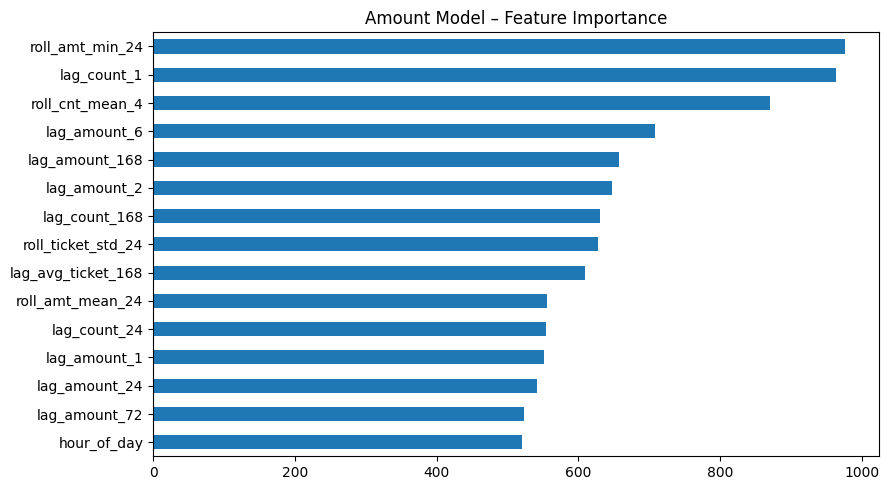

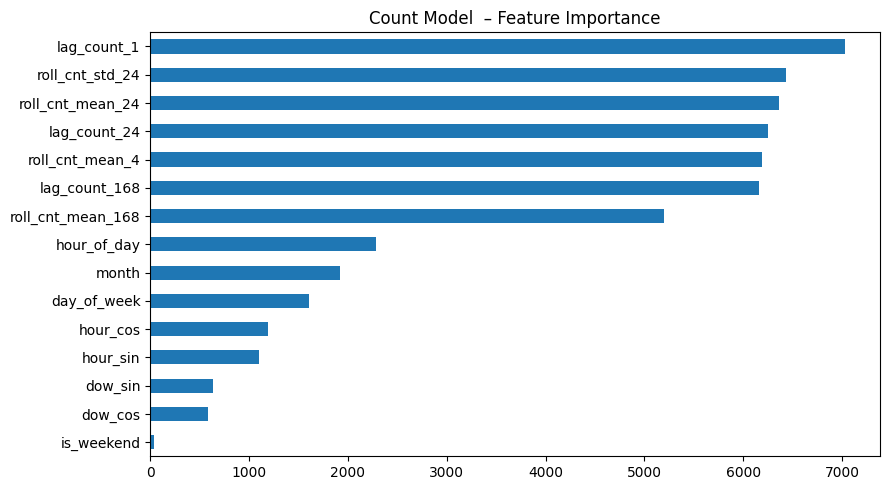

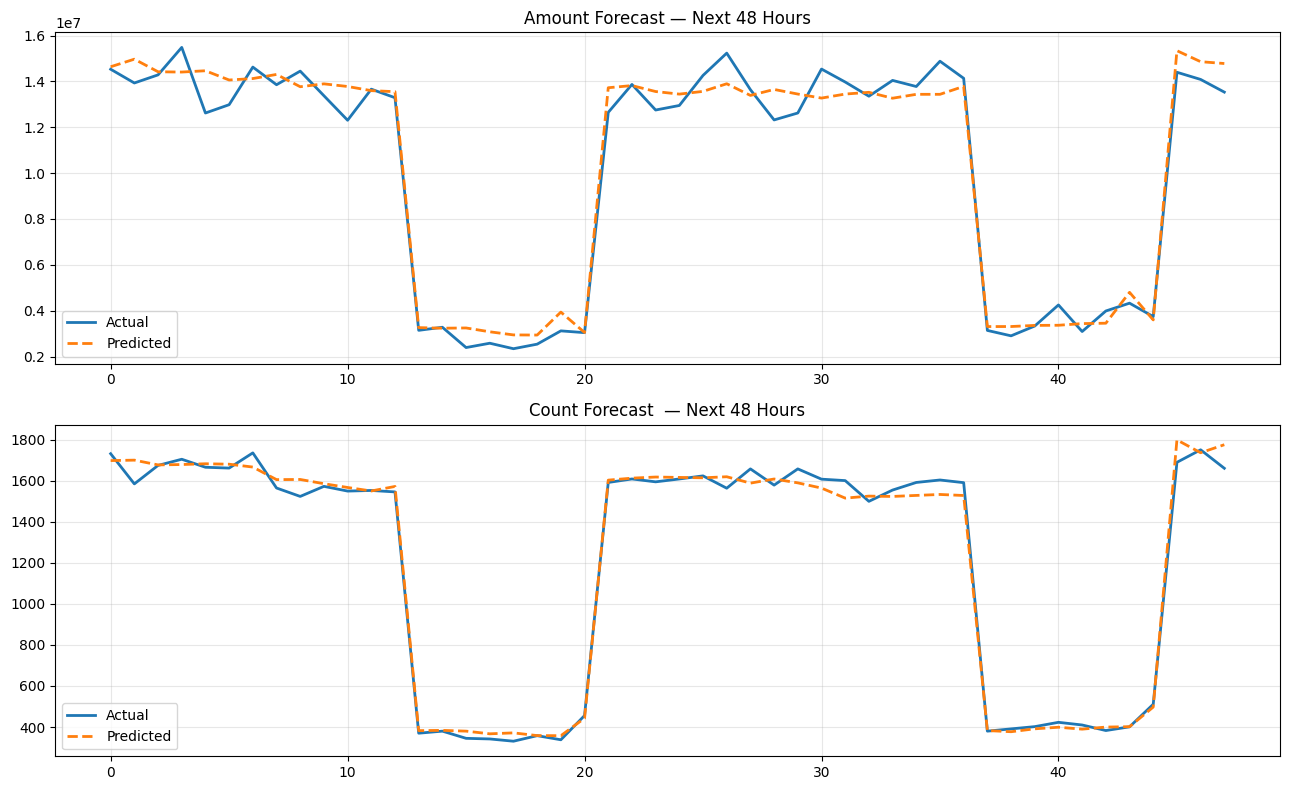

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import optuna
import warnings
warnings.filterwarnings("ignore")

from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

# 1) METRICS
def smape(y_true, y_pred, eps=1e-9):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom  = np.maximum((np.abs(y_true) + np.abs(y_pred)) / 2.0, eps)
    return np.mean(np.abs(y_true - y_pred) / denom) * 100

def eval_metrics(y_true, y_pred, label=""):
    m = {
        "MAE":      mean_absolute_error(y_true, y_pred),
        "RMSE":     np.sqrt(mean_squared_error(y_true, y_pred)),
        "sMAPE(%)": smape(y_true, y_pred),
        "R2":       r2_score(y_true, y_pred),
    }
    if label:
        print(f"\n{'='*40}")
        print(f"  {label}")
        print(f"{'='*40}")
        for k, v in m.items():
            print(f"  {k:10s}: {v:,.4f}")
    return m

# 2) LOAD
df = pd.read_csv("aml_data/SAML-D.csv")
df["timestamp"] = pd.to_datetime(df["Date"] + " " + df["Time"])
df = df.sort_values("timestamp").reset_index(drop=True)

hourly = (
    df.set_index("timestamp")
      .resample("H")
      .agg(Amount=("Amount", "sum"), tx_count=("Amount", "count"))
      .reset_index()
)
hourly["Amount"]   = hourly["Amount"].fillna(0)
hourly["tx_count"] = hourly["tx_count"].fillna(0)
print(f"Total hours: {len(hourly)}")

# 3) FEATURE ENGINEERING
def build_features(hourly: pd.DataFrame) -> pd.DataFrame:
    h = hourly.copy()

    h["hour_of_day"] = h["timestamp"].dt.hour
    h["day_of_week"] = h["timestamp"].dt.dayofweek
    h["month"]       = h["timestamp"].dt.month
    h["is_weekend"]  = (h["day_of_week"] >= 5).astype(int)
    h["hour_sin"]    = np.sin(2 * np.pi * h["hour_of_day"] / 24)
    h["hour_cos"]    = np.cos(2 * np.pi * h["hour_of_day"] / 24)
    h["dow_sin"]     = np.sin(2 * np.pi * h["day_of_week"] / 7)
    h["dow_cos"]     = np.cos(2 * np.pi * h["day_of_week"] / 7)

    # avg_ticket
    h["avg_ticket"] = (h["Amount"] / h["tx_count"].replace(0, np.nan)).fillna(0)

    # Zero-activity flag
    h["is_zero_hour"] = (h["tx_count"] == 0).astype(int)

    # ── Lag features ──────────────────────────────────────────
    for lag in [1, 2, 3, 6, 12, 24, 48, 72, 168]:
        h[f"lag_amount_{lag}"] = h["Amount"].shift(lag)

    for lag in [1, 24, 168]:
        h[f"lag_count_{lag}"]      = h["tx_count"].shift(lag)
        h[f"lag_avg_ticket_{lag}"] = h["avg_ticket"].shift(lag)
        h[f"lag_zero_{lag}"]       = h["is_zero_hour"].shift(lag)

    # ── Rolling features ──
    amt_s    = h["Amount"].shift(1)
    cnt_s    = h["tx_count"].shift(1)
    ticket_s = h["avg_ticket"].shift(1)

    # Amount rolling
    for w in [4, 24, 168]:
        h[f"roll_amt_mean_{w}"] = amt_s.rolling(w).mean()
    h["roll_amt_std_24"]  = amt_s.rolling(24).std()
    h["roll_amt_std_168"] = amt_s.rolling(168).std()
    h["roll_amt_max_24"]  = amt_s.rolling(24).max()
    h["roll_amt_min_24"]  = amt_s.rolling(24).min()

    # Count rolling
    for w in [4, 24, 168]:
        h[f"roll_cnt_mean_{w}"] = cnt_s.rolling(w).mean()
    h["roll_cnt_std_24"] = cnt_s.rolling(24).std()

    # Avg-ticket rolling
    h["roll_ticket_mean_24"] = ticket_s.rolling(24).mean()
    h["roll_ticket_std_24"]  = ticket_s.rolling(24).std()

    # ── Interaction feature ───────────────────────────────────
    h["amt_momentum"] = h["roll_amt_mean_4"] / (h["roll_amt_mean_168"] + 1)

    return h.dropna().reset_index(drop=True)


hourly_fe = build_features(hourly)
print(f"After feature engineering: {hourly_fe.shape}")

# 4) FEATURE SETS
EXCLUDE_ALWAYS = {"timestamp", "Amount", "tx_count", "avg_ticket", "is_zero_hour"}

amount_features = [c for c in hourly_fe.columns if c not in EXCLUDE_ALWAYS]

count_exclude = EXCLUDE_ALWAYS | {
    c for c in hourly_fe.columns
    if any(x in c for x in ["amount", "amt", "ticket", "momentum"])
}
count_features = [c for c in hourly_fe.columns if c not in count_exclude]

print(f"\nAmount features ({len(amount_features)}): {amount_features}")
print(f"Count  features ({len(count_features)}):  {count_features}")

# ─────────────────────────────────────────────────────────────
# 5) WALK-FORWARD CROSS-VALIDATION
# ─────────────────────────────────────────────────────────────
H        = 48
N        = len(hourly_fe)
MIN_TRAIN = 500   # burn-in rows before first fold
N_FOLDS   = 8    # number of folds to evaluate

fold_starts = np.linspace(MIN_TRAIN, N - H - 1, N_FOLDS, dtype=int)

def walk_forward_cv(features, target_col, params, n_folds=N_FOLDS):
    fold_scores = []
    for fold_end in fold_starts:
        train_idx = hourly_fe.index[:fold_end]
        test_idx  = hourly_fe.index[fold_end : fold_end + H]

        X_tr = hourly_fe.loc[train_idx, features]
        y_tr = hourly_fe.loc[train_idx, target_col]
        X_te = hourly_fe.loc[test_idx,  features]
        y_te = hourly_fe.loc[test_idx,  target_col]

        m = LGBMRegressor(**params, random_state=42, verbose=-1)
        m.fit(X_tr, y_tr)
        preds = np.maximum(m.predict(X_te), 0)
        fold_scores.append(smape(y_te.values, preds))

    return np.mean(fold_scores), np.std(fold_scores)

print("\n[CV] Running walk-forward CV with default params to establish baseline...")
default_amt_params = dict(n_estimators=1000, learning_rate=0.02,
                          num_leaves=63, min_child_samples=20,
                          subsample=0.85, colsample_bytree=0.85,
                          reg_alpha=0.1, reg_lambda=0.1)

cv_mean, cv_std = walk_forward_cv(amount_features, "Amount", default_amt_params)
print(f"  Baseline Amount sMAPE (CV): {cv_mean:.3f}% ± {cv_std:.3f}%")

# 6) OPTUNA HYPERPARAMETER TUNING
def tune_model(features, target_col, n_trials=40):
    def objective(trial):
        params = dict(
            n_estimators     = trial.suggest_int("n_estimators", 400, 1500),
            learning_rate    = trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
            num_leaves       = trial.suggest_int("num_leaves", 15, 127),
            min_child_samples= trial.suggest_int("min_child_samples", 10, 60),
            subsample        = trial.suggest_float("subsample", 0.6, 1.0),
            colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0),
            reg_alpha        = trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
            reg_lambda       = trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        )
        mean_smape, _ = walk_forward_cv(features, target_col, params)
        return mean_smape

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study.best_params

print("\n[Optuna] Tuning Amount model...")
best_amt_params  = tune_model(amount_features, "Amount",   n_trials=40)
print(f"  Best Amount params:  {best_amt_params}")

print("\n[Optuna] Tuning Count model...")
best_cnt_params  = tune_model(count_features,  "tx_count", n_trials=40)
print(f"  Best Count params:   {best_cnt_params}")

# 7) FINAL TRAIN / TEST  (last 48 hours held out)
train = hourly_fe.iloc[:-H]
test  = hourly_fe.iloc[-H:]

X_train_amt = train[amount_features];  X_test_amt = test[amount_features]
X_train_cnt = train[count_features];   X_test_cnt = test[count_features]

y_train_amt = train["Amount"];         y_test_amt = test["Amount"]
y_train_cnt = train["tx_count"];       y_test_cnt = test["tx_count"]

# 8) TRAIN FINAL MODELS
model_amount = LGBMRegressor(**best_amt_params, random_state=42, verbose=-1)
model_count  = LGBMRegressor(**best_cnt_params, random_state=42, verbose=-1)

model_amount.fit(X_train_amt, y_train_amt)
model_count.fit(X_train_cnt,  y_train_cnt)

# 9) ENSEMBLE: blend LightGBM with seasonal naive
naive_amt = test["lag_amount_168"].values
naive_cnt = test["lag_count_168"].values

lgbm_amt = np.maximum(model_amount.predict(X_test_amt), 0)
lgbm_cnt = np.maximum(model_count.predict(X_test_cnt),  0)

best_alpha, best_cv = 0.0, 9999
for alpha in np.arange(0.0, 0.41, 0.05):
    blended = (1 - alpha) * lgbm_amt + alpha * naive_amt
    s = smape(y_test_amt.values, blended)
    if s < best_cv:
        best_cv, best_alpha = s, alpha

print(f"\n[Ensemble] Best naive blend weight (amount): {best_alpha:.2f}  →  sMAPE {best_cv:.3f}%")

pred_amount = (1 - best_alpha) * lgbm_amt + best_alpha * naive_amt
pred_count  = lgbm_cnt

# 10) EVALUATE
eval_metrics(y_test_amt.values, pred_amount, "Amount Forecast (Tuned + Ensemble)")
eval_metrics(y_test_cnt.values, pred_count,  "Count Forecast  (Tuned)")

avg_vol = hourly_fe["Amount"].mean()
mae_pct = mean_absolute_error(y_test_amt.values, pred_amount) / avg_vol * 100
print(f"\n  MAE as % of avg hourly volume: {mae_pct:.2f}%")

# 11) FEATURE IMPORTANCE
def plot_importance(model, features, title, top_n=15):
    imp = pd.Series(model.feature_importances_, index=features)
    imp.nlargest(top_n).sort_values().plot(kind="barh", figsize=(9, 5))
    plt.title(title); plt.tight_layout(); plt.show()

plot_importance(model_amount, amount_features, "Amount Model – Feature Importance")
plot_importance(model_count,  count_features,  "Count Model  – Feature Importance")

# 12) PLOTS
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

axes[0].plot(y_test_amt.values, label="Actual",    lw=2)
axes[0].plot(pred_amount,       label="Predicted", lw=2, ls="--")
axes[0].set_title(f"Amount Forecast — Next {H} Hours"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(y_test_cnt.values, label="Actual",    lw=2)
axes[1].plot(pred_count,        label="Predicted", lw=2, ls="--")
axes[1].set_title(f"Count Forecast  — Next {H} Hours"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()